<a href="https://colab.research.google.com/github/tirthas970-cmyk/AeroTrack-Prime/blob/main/Clean_X_Class_Solar_Flare_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sunpy[all] drms


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 971.7/971.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.8/105.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━

Mounted at /content/drive


INFO:sunpy:12 URLs found for download. Full request totaling 3MB


INFO: 12 URLs found for download. Full request totaling 3MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/12 [00:00<?, ?file/s]

hmi.sharp_cea_720s.7117.20170901_000000_TAI.magnetogram.fits:   0%|          | 0.00/536k [00:00<?, ?B/s]

...

hmi.sharp_cea_720s.7117.20170901_001200_TAI.magnetogram.fits:   0%|          | 0.00/536k [00:00<?, ?B/s]

hmi.sharp_cea_720s.7120.20170901_000000_TAI.magnetogram.fits:   0%|          | 0.00/112k [00:00<?, ?B/s]

hmi.sharp_cea_720s.7120.20170901_001200_TAI.magnetogram.fits:   0%|          | 0.00/115k [00:00<?, ?B/s]

hmi.sharp_cea_720s.7121.20170901_000000_TAI.magnetogram.fits:   0%|          | 0.00/43.2k [00:00<?, ?B/s]

hmi.sharp_cea_720s.7121.20170901_001200_TAI.magnetogram.fits:   0%|          | 0.00/43.2k [00:00<?, ?B/s]

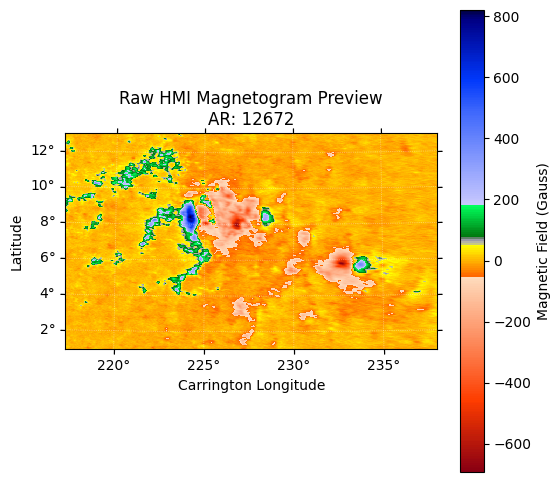

In [3]:
#This script is just a sample that shows 1 magnetogram before normalization and labeling

from pathlib import Path
import sunpy.map
from sunpy.net import Fido, attrs as a
import astropy.units as u
import matplotlib.pyplot as plt
from google.colab import drive, userdata

drive.mount('/content/drive')
jsoc_email = userdata.get("jsoc_email")

sample_search = Fido.search(
    a.Time("2017-09-01T00:00:00", "2017-09-01T00:12:00"),
    a.jsoc.Series("hmi.sharp_cea_720s"),
    a.jsoc.Segment("magnetogram"),
    a.jsoc.Notify(jsoc_email)
)

if sample_search:
    print("Downloading sample FITS file")
    one_file = Fido.fetch(sample_search[0][0])

    raw_map = sunpy.map.Map(one_file[0])
    plt.figure(figsize=(6, 6))
    raw_map.plot(cmap='hmimag') # Uses the offical color table to render it
    plt.colorbar(label="Magnetic Field (Gauss)")
    plt.title(f"Raw HMI Magnetogram Preview\nAR: {raw_map.meta.get('noaa_ar', 'Unknown')}")
    plt.show()
    Path(one_file[0]).unlink(missing_ok=True)
else:
    print("Could not find a sample image. Check your JSOC email or time window.")


In [ ]:
# This script downloads the magnetograms from SHARP, normalizes them, converts them into .npy files, and labels them based on X-class Flare

from pathlib import Path
import os
import sunpy.map
from sunpy.net import Fido, attrs as a
from sunpy.net.hek import HEKClient
import pandas as pd
import numpy as np
import astropy.units as u
from google.colab import userdata, drive

print("Connecting to Google Drive")
drive.mount('/content/drive')

#Time for testing
start_time = "2017-09-01T00:00:00"
end_time = "2017-10-01T00:00:00"

jsoc_email = userdata.get("jsoc_email") #This is a secret key
output_folder = Path("/content/drive/My Drive/unified_solar_dataset")
output_folder.mkdir(parents=True, exist_ok=True)

# Part 1) Download all images
print("Checking image availability index")
search_results = Fido.search(
    a.Time(start_time, end_time),
    a.jsoc.Series("hmi.sharp_cea_720s"), # CEA --> cylindrical area mapping, which remaps the megneogram to be uniform and flat (2D)
    a.jsoc.Segment("magnetogram"),
    a.Sample(14400 * u.s), # 4 hours
    a.jsoc.Notify(jsoc_email)
)

if not search_results:
    print("No images matched the query criteria.")
    exit()

jsoc_meta = search_results['jsoc']
total_records = len(jsoc_meta)

print(f" Found {total_records} images to collect.")

print("Downloading the files")
downloaded_files = Fido.fetch(search_results)

if not downloaded_files:
    print(" Download failed or server queue timed out.")
    exit()

print(f"\nSuccessfully downloaded {len(downloaded_files)} raw FITS files.")
print("Processing and converting raw downloads into float32 .npy arrays...")

for file_path in downloaded_files:
    try:
        sharp_map = sunpy.map.Map(file_path)
        noaa_string = sharp_map.meta.get('noaa_ars', '')
        try:
            sharp_ar = int(noaa_string.split(',')[0].strip()) if noaa_string else int(sharp_map.meta.get('noaa_ar', 0))
        except (ValueError, TypeError):
            sharp_ar = int(sharp_map.meta.get('noaa_ar', 0))

        if sharp_ar == 0:
            print(f" Warning: Could not find valid NOAA AR for {file_path}. Skipping file.")
            Path(file_path).unlink(missing_ok=True)
            continue

        t_rec_str = sharp_map.meta.get('t_rec', '').replace('_TAI', '').replace('_', ' ')
        img_time = pd.to_datetime(t_rec_str)
        filename = f"AR{sharp_ar}_{img_time.strftime('%Y%m%d_%H%M%S')}.npy"

        if (output_folder / filename).exists() or \
           (output_folder / filename.replace(".npy", "_LABEL0.npy")).exists() or \
           (output_folder / filename.replace(".npy", "_LABEL1.npy")).exists():
            Path(file_path).unlink(missing_ok=True)
            continue

        #Normalizing the images into [0, 1]
        raw_pixels = np.nan_to_num(sharp_map.data).astype(np.float32)
        norm_pixels = ((np.clip(raw_pixels, -4000, 4000) + 4000) / 8000.0).astype(np.float32)

        np.save(output_folder / filename, norm_pixels)
        Path(file_path).unlink(missing_ok=True)
    except Exception as e:
        print(f" Error processing file {file_path}: {e}")
        Path(file_path).unlink(missing_ok=True)

print("Phase 1 Complete! Images are saved to drive")


# Part 2) Fetch flare log and label the npy images
print(" Starting Phase 2: Fetching the entire multi-year flare log from HEK")
hek_client = HEKClient()
event_search = hek_client.search(
    a.Time(start_time, pd.to_datetime(end_time) + pd.Timedelta(days=2)), # Added 2 days because it is often catolgoed a few days after image is taken
    a.hek.EventType("FL"),
    a.hek.FL.GOESCls > "X1.0"
)

if event_search:
    df_flares = event_search[[name for name in event_search.colnames if len(event_search[name].shape) <= 1]].to_pandas()
    df_flares['ar_noaanum'] = pd.to_numeric(df_flares['ar_noaanum'], errors='coerce') # Coerce to covert invalid datatypes to NaNs
    df_flares['event_starttime'] = pd.to_datetime(df_flares['event_starttime'])
else:
    df_flares = pd.DataFrame(columns=['ar_noaanum', 'event_starttime'])

print(" Scanning your folder and applying labels to the files")
npy_files = [f for f in os.listdir(output_folder) if f.endswith('.npy') and "_LABEL" not in f]

for file_name in npy_files:
    try:
        parts = file_name.replace('.npy', '').split('_')
        arp_num = int(parts[0].replace('AR', ''))
        time_str = f"{parts[1]}_{parts[2]}"
        img_time = pd.to_datetime(time_str, format='%Y%m%d_%H%M%S')

        # Checks if these conditionsa are true in order to label
        flare_match = df_flares[
            (df_flares['ar_noaanum'] == arp_num) &
            (df_flares['event_starttime'] > img_time) &
            (df_flares['event_starttime'] <= img_time + pd.Timedelta(hours=24))
        ]

        # 1 -> X - Class
        # 0 -> Not X - Class
        label = 1 if not flare_match.empty else 0
        old_path = output_folder / file_name
        new_filename = file_name.replace(".npy", f"_LABEL{label}.npy")
        new_path = output_folder / new_filename
        os.rename(old_path, new_path)
        print(f"Renamed and labeled: {file_name} ➔ {new_filename}")
    except Exception as e:
        print(f"Could not label file {file_name}: {e}")

print("Forcing Google Drive to sync all data safely")
drive.flush_and_unmount()
print("Mapped images downloaded, labeled, and saved to your real Drive storage permanently!")
